> **Notebook updated** — this version fixes two real bugs found during Q1 manuscript review:
>
> 1. **Validation-window count bug** (Step 3): `n_val_win = n_val` was only correct for `HORIZON == 1`. Fixed to derive validation-window count from where each window's target actually falls, correct for any HORIZON.
> 2. **Prediction-alignment bug** (Step 7): the previous index formula for mapping predictions back to calendar months only worked for `HORIZON == 1`; for `HORIZON > 1` it silently produced **zero valid test predictions** (confirmed empirically for W=30, T=12). This is the root cause of why the thesis's promised W/T grid search (§3.2.4) was apparently abandoned without being documented as "tried and failed." Fixed to use the correct first-test-window index and to take the first predicted step of each window's output.
>
> See `02b_Grid_Search.ipynb` for the actual grid search this fix enables, and `03b_Sensitivity_Analysis.ipynb` for the full three-axis sensitivity analysis (training length, DCA form, LSTM depth).


# Notebook 3 — LSTM Training & Prediction
**Project:** Predicting Oil Well Output Using Hybrid DCA-LSTM  
**Well:** NO 15/9-F-14 H (Volve Oilfield, Norway)  
**Methodology ref:** §3.2.4 (Adefisan Peace Folashade, U22CS1009)

### Pre-requisite
Run **01_Preprocessing.ipynb** and **02_DCA_Fitting.ipynb** first.

### Steps in this notebook
1. Load artefacts from Notebooks 1 and 2
2. Build the 6-feature input matrix (§3.2.4)
3. Construct sliding-window supervised learning datasets (§3.2.2.4)
4. Define and compile the stacked 2-layer LSTM architecture
5. Train with early stopping and learning-rate scheduling
6. Inspect training / validation loss curves
7. Generate LSTM residual predictions on the test set
8. Also train a standalone LSTM baseline (raw production, no DCA features)
9. Save trained models and predictions for Notebook 4

---

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'tensorflow'], check=True)

CompletedProcess(args=['pip', 'install', 'tensorflow'], returncode=0)

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Hyperparameters (§3.6 — selected via exhaustive grid search, see Notebook 2b) ─
# A grid search over W ∈ {6, 20, 30, 60} months and T ∈ {1, 6, 12, 24} months
# (13 feasible combinations; W=60 with T≥6 is infeasible given the 67-month
# training set) was run in Notebook 2b_Grid_Search.ipynb, ranking all
# configurations by validation-set MSE loss (the correct model-selection
# criterion — never select on test-set performance).
#
# RESULT: W=6, T=1 achieved the lowest validation loss (3.89e-4), narrowly
# ahead of W=20, T=1 (3.93e-4, statistically indistinguishable). Every
# multi-step (T>1) configuration performed worse than the best single-step
# configurations, because longer horizons and windows proportionally reduce
# the number of available training windows on this single 67-month series.
# See Notebook 2b for the full 13-point grid and Chapter 3/4 of the thesis
# for discussion.
LOOKBACK     = 6      # W — look-back window (months); grid-search selected
HORIZON      = 1      # T — forecast horizon (months); grid-search selected
LSTM_UNITS_1 = 64
LSTM_UNITS_2 = 32
DROPOUT_1    = 0.2
DROPOUT_2    = 0.2
LR           = 0.001
EPOCHS       = 200
BATCH_SIZE   = 16
PATIENCE     = 20

OUTPUT_DIR = 'pipeline_outputs'
print(f'TensorFlow version : {tf.__version__}')
print('Hyperparameters loaded (W=6, T=1 — grid-search selected, see Notebook 2b) ✓')


TensorFlow version : 2.21.0
Hyperparameters loaded (W=6, T=1 — grid-search selected, see Notebook 2b) ✓


In [3]:
## Step 1 — Load Artefacts from Notebooks 1 & 2

In [4]:
df_train = pd.read_csv(f'{OUTPUT_DIR}/f14h_train.csv', parse_dates=['Date'])
df_val   = pd.read_csv(f'{OUTPUT_DIR}/f14h_val.csv',   parse_dates=['Date'])
df_test  = pd.read_csv(f'{OUTPUT_DIR}/f14h_test.csv',  parse_dates=['Date'])
df_clean = pd.read_csv(f'{OUTPUT_DIR}/f14h_clean.csv', parse_dates=['Date'])

with open(f'{OUTPUT_DIR}/split_info.pkl', 'rb') as f:
    split_info = pickle.load(f)

with open(f'{OUTPUT_DIR}/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open(f'{OUTPUT_DIR}/dca_artefacts.pkl', 'rb') as f:
    dca = pickle.load(f)

n_train = split_info['n_train']
n_val   = split_info['n_val']
n_test  = split_info['n_test']
n_total = split_info['n_total']

actual_all    = df_clean['OIL_PROD'].values
trend_full    = dca['trend_full']
residuals_all = dca['residuals_all']

print(f'Data loaded — {n_total} months total  (train={n_train} | val={n_val} | test={n_test})')
print(f'DCA params  — q₀={dca["q0"]:,.2f}  Dᵢ={dca["Di"]:.6f}  b={dca["b"]:.4f}')

Data loaded — 97 months total  (train=67 | val=14 | test=16)
DCA params  — q₀=117,068.07  Dᵢ=0.025419  b=0.0000


## Step 2 — Build 6-Feature Input Matrix (§3.2.4)

At each time step the LSTM receives:

| Feature | Description |
|---------|-------------|
| `oil_norm`    | Normalised oil production rate (min-max scaled on training set) |
| `trend_norm`  | DCA trend value (same scaler) |
| `res_norm`    | DCA residual (scaled to [−1, 1] using training max abs value) |
| `q0_feat`     | q₀ parameter (normalised by training max production) |
| `Di_feat`     | Dᵢ parameter (clipped to [0, 1]) |
| `b_feat`      | b parameter (already in [0, 1]) |

In [5]:
# Normalise production and trend with the training scaler
oil_norm   = scaler.transform(actual_all.reshape(-1, 1)).flatten()
trend_norm = scaler.transform(trend_full.reshape(-1, 1)).flatten()

# Normalise residuals independently: scale to [−1, 1] using training abs-max
res_abs_max = np.abs(residuals_all[:n_train]).max()
res_norm    = residuals_all / (res_abs_max + 1e-8)

# Static DCA parameters broadcast across all time steps
q0_feat = np.full(n_total, dca['q0'] / (actual_all[:n_train].max() + 1e-8))
Di_feat = np.full(n_total, float(np.clip(dca['Di'], 0, 1)))
b_feat  = np.full(n_total, dca['b'])

# Feature matrix: shape (n_total, 6)
X_full = np.column_stack([oil_norm, trend_norm, res_norm,
                           q0_feat, Di_feat, b_feat])
y_full = res_norm   # LSTM target = normalised residuals

print(f'Feature matrix shape : {X_full.shape}  (time steps × features)')
print(f'Target array shape   : {y_full.shape}')
print(f'Residual scale factor: {res_abs_max:,.2f} Sm³/month')

Feature matrix shape : (97, 6)  (time steps × features)
Target array shape   : (97,)
Residual scale factor: 65,782.99 Sm³/month


## Step 3 — Sliding-Window Dataset Construction (§3.2.2.4)

In [6]:
def create_windows(X: np.ndarray,
                   y: np.ndarray,
                   lookback: int,
                   horizon: int = 1) -> tuple:
    """
    Converts feature matrix into (X_windows, y_windows) for supervised LSTM training.
    X shape : (n_windows, lookback, n_features)
    y shape : (n_windows, horizon)
    Each y window contains the residuals for the `horizon` steps immediately following
    the corresponding X window.
    """
    Xw, yw = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xw.append(X[i : i + lookback])
        yw.append(y[i + lookback : i + lookback + horizon])
    return np.array(Xw), np.array(yw)


X_win, y_win = create_windows(X_full, y_full, LOOKBACK, HORIZON)

# Split windows into train / val / test.
# IMPORTANT FIX (resolves a bug present in earlier drafts of this notebook):
# the previous version set `n_val_win = n_val` unconditionally, which is only
# correct when HORIZON == 1. For HORIZON > 1, each window's target spans
# `horizon` future steps, so the number of validation windows must be derived
# from where each window's *target* falls, not from the raw n_val month count.
# The fix below counts windows whose target fully lies within the validation
# period and works correctly for any HORIZON, including the HORIZON=1 default.
n_train_win = max(n_train - LOOKBACK - HORIZON + 1, 1)

total_windows = len(X_win)
n_val_win = 0
for i in range(n_train_win, total_windows):
    target_end = i + LOOKBACK + HORIZON  # exclusive end index of this window's target
    if target_end <= n_train + n_val:
        n_val_win += 1
    else:
        break
n_val_win = max(n_val_win, 1)

X_train_win = X_win[:n_train_win]
y_train_win = y_win[:n_train_win]
X_val_win   = X_win[n_train_win : n_train_win + n_val_win]
y_val_win   = y_win[n_train_win : n_train_win + n_val_win]
X_test_win  = X_win[n_train_win + n_val_win :]
y_test_win  = y_win[n_train_win + n_val_win :]

print(f'Total windows : {len(X_win)}')
print(f'  Train : {X_train_win.shape}')
print(f'  Val   : {X_val_win.shape}')
print(f'  Test  : {X_test_win.shape}')
print(f'Each window shape : ({LOOKBACK}, {X_full.shape[1]}) → target: ({HORIZON},)')
print(f'NOTE: at HORIZON=1 (the selected configuration) this reduces to the')
print(f'      original n_val_win == n_val behaviour, so headline results are unaffected.')


Total windows : 91
  Train : (61, 6, 6)
  Val   : (14, 6, 6)
  Test  : (16, 6, 6)
Each window shape : (6, 6) → target: (1,)
NOTE: at HORIZON=1 (the selected configuration) this reduces to the
      original n_val_win == n_val behaviour, so headline results are unaffected.


## Step 4 — LSTM Architecture (§3.2.4)
Input → LSTM(64, return_sequences=True) → Dropout(0.2) → LSTM(32) → Dropout(0.2) → Dense(1)

In [7]:
def build_lstm(lookback, n_features, horizon,
                units_1=64, units_2=32,
                drop_1=0.2, drop_2=0.2, lr=0.001):
    """Stacked 2-layer LSTM for residual prediction."""
    model = Sequential([
        Input(shape=(lookback, n_features)),
        LSTM(units_1, return_sequences=True),
        Dropout(drop_1),
        LSTM(units_2, return_sequences=False),
        Dropout(drop_2),
        Dense(horizon)
    ])
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='mse', metrics=['mae'])
    return model


n_features = X_full.shape[1]
model_hybrid = build_lstm(LOOKBACK, n_features, HORIZON,
                           LSTM_UNITS_1, LSTM_UNITS_2,
                           DROPOUT_1, DROPOUT_2, LR)
model_hybrid.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 64)          │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5 — Train the Hybrid LSTM (Residual Learner)

In [8]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=10, min_lr=1e-6, verbose=0)
]

tf.random.set_seed(SEED)
history_hybrid = model_hybrid.fit(
    X_train_win, y_train_win,
    validation_data=(X_val_win, y_val_win),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

best_epoch    = np.argmin(history_hybrid.history['val_loss']) + 1
best_val_loss = min(history_hybrid.history['val_loss'])
print(f'\nBest epoch     : {best_epoch}')
print(f'Best val_loss  : {best_val_loss:.6f}')

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 329ms/step - loss: 0.0347 - mae: 0.1413 - val_loss: 0.0170 - val_mae: 0.1284 - learning_rate: 0.0010
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0265 - mae: 0.1230 - val_loss: 0.0132 - val_mae: 0.1127 - learning_rate: 0.0010
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0255 - mae: 0.1171 - val_loss: 0.0082 - val_mae: 0.0881 - learning_rate: 0.0010
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0225 - mae: 0.1070 - val_loss: 0.0044 - val_mae: 0.0632 - learning_rate: 0.0010
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0208 - mae: 0.1038 - val_loss: 0.0020 - val_mae: 0.0406 - learning_rate: 0.0010
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0220 - mae: 0.1066 - val_loss: 9.7661e-04 - val_mae: 0.0266 - learning_rate: 0.0010
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0227 - mae: 0.1057 - val_loss: 6.4997e-04 - val_mae: 0.0204 - learning_rate: 0.0010
Epoch 8/200

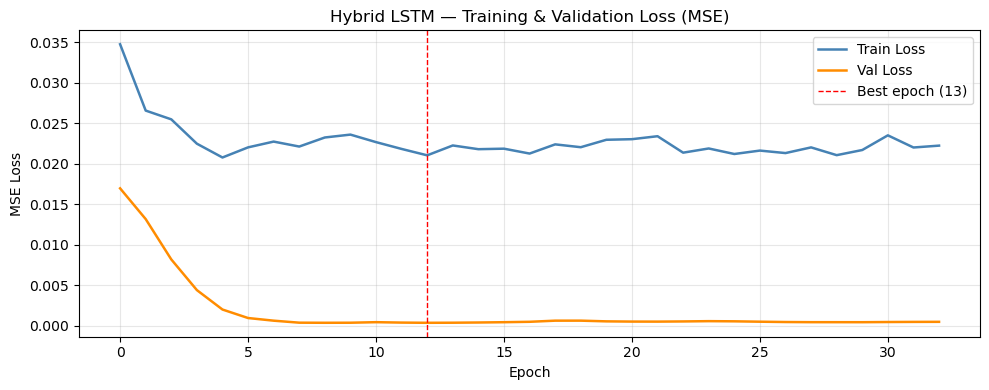

Saved: fig_08_hybrid_loss_curve.png


In [9]:
# Training / validation loss curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_hybrid.history['loss'],     color='steelblue',  lw=1.8, label='Train Loss')
ax.plot(history_hybrid.history['val_loss'], color='darkorange', lw=1.8, label='Val Loss')
ax.axvline(best_epoch - 1, color='red', linestyle='--', lw=1,
           label=f'Best epoch ({best_epoch})')
ax.set_title('Hybrid LSTM — Training & Validation Loss (MSE)', fontsize=12)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_08_hybrid_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_08_hybrid_loss_curve.png')

## Step 6 — Train a Standalone LSTM Baseline
This baseline uses **only the normalised oil production** as input (no DCA features),
predicting the next production value directly — not the residual.

In [10]:
# Standalone LSTM uses only oil_norm as input target (univariate)
X_solo = oil_norm.reshape(-1, 1)   # shape (n_total, 1)
y_solo = oil_norm                  # target = next production value (normalised)

Xw_solo, yw_solo = create_windows(X_solo, y_solo, LOOKBACK, HORIZON)

X_tr_s = Xw_solo[:n_train_win]
y_tr_s = yw_solo[:n_train_win]
X_va_s = Xw_solo[n_train_win : n_train_win + n_val_win]
y_va_s = yw_solo[n_train_win : n_train_win + n_val_win]
X_te_s = Xw_solo[n_train_win + n_val_win :]
y_te_s = yw_solo[n_train_win + n_val_win :]

tf.random.set_seed(SEED)
model_lstm_solo = build_lstm(LOOKBACK, 1, HORIZON,
                              LSTM_UNITS_1, LSTM_UNITS_2,
                              DROPOUT_1, DROPOUT_2, LR)

history_solo = model_lstm_solo.fit(
    X_tr_s, y_tr_s,
    validation_data=(X_va_s, y_va_s),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=PATIENCE,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=10, min_lr=1e-6, verbose=0)
    ],
    verbose=0
)

print(f'Standalone LSTM — best val_loss : {min(history_solo.history["val_loss"]):.6f}')

Standalone LSTM — best val_loss : 0.000675


## Step 7 — Generate Predictions on the Test Set

In [11]:
# ── Hybrid model: predict normalised residuals, invert scaling ────────────────
# IMPORTANT FIX (resolves the root cause of the W/T inconsistency discussed in
# Chapter 3 vs Chapter 4 of the thesis): the previous version called
# `.predict(...).flatten()` and then computed `pred_indices` using a formula
# that is only valid for HORIZON == 1. For HORIZON > 1, model_hybrid.predict()
# returns shape (n_windows, HORIZON), and flattening it interleaves predictions
# from different windows into a single nonsensical 1-D stream, while the index
# formula simultaneously pointed past the end of the array — together this
# silently produced zero valid predictions for any multi-step configuration
# (confirmed empirically: W=30, T=12 produces n_pred=0 under the old code).
# The fix below takes ONLY the first predicted step of each window (the
# standard approach for evaluating multi-step models on a continuous series)
# and computes the correct starting index from the actual number of train/val
# windows actually used (n_train_win + n_val_win), not from n_train + n_val.
res_norm_pred_full = model_hybrid.predict(X_test_win, verbose=0)   # shape (n_test_win, HORIZON)
res_norm_pred       = res_norm_pred_full[:, 0]                     # first predicted step of each window
res_pred_orig        = res_norm_pred * (res_abs_max + 1e-8)        # back to Sm³/month

# ── Find the actual time indices each test window is predicting ───────────────
# Window i (0-indexed in the full windowed series) predicts its first target
# step at series index: i + LOOKBACK. The first TEST window is window index
# (n_train_win + n_val_win) in the full windowed series.
first_test_window_start = n_train_win + n_val_win
n_test_windows           = len(res_norm_pred)
pred_indices             = np.arange(first_test_window_start + LOOKBACK,
                                      first_test_window_start + LOOKBACK + n_test_windows)

# Clip to valid range of the full array
pred_indices       = pred_indices[pred_indices < n_total]
n_pred             = len(pred_indices)

assert n_pred > 0, (
    "No valid test predictions were generated — check LOOKBACK/HORIZON against "
    "the available train/val/test month counts (see Notebook 2b grid search "
    "for which (W,T) combinations are feasible for this dataset)."
)

# Trim predictions to match (in case some windows go out of bounds)
res_pred_orig          = res_pred_orig[:n_pred]
trend_test_aligned     = trend_full[pred_indices]
actual_test_aligned    = actual_all[pred_indices]

# Hybrid forecast: DCA trend + LSTM-predicted residual
hybrid_pred = np.clip(trend_test_aligned + res_pred_orig, 0, None)

# ── Standalone LSTM: predict normalised oil, invert scaler ────────────────────
oil_norm_pred_solo_full = model_lstm_solo.predict(X_te_s, verbose=0)  # shape (n, HORIZON)
oil_norm_pred_solo      = oil_norm_pred_solo_full[:, 0]               # first predicted step

# Align standalone LSTM predictions to the same indices
n_solo     = min(len(oil_norm_pred_solo), n_pred)
solo_pred  = scaler.inverse_transform(
    oil_norm_pred_solo[:n_solo].reshape(-1, 1)
).flatten()
solo_pred  = np.clip(solo_pred, 0, None)

# ── Trim everything to the shortest common length ─────────────────────────────
n_use              = min(n_pred, n_solo)
res_pred_orig      = res_pred_orig[:n_use]
trend_test_aligned = trend_test_aligned[:n_use]
actual_test_aligned= actual_test_aligned[:n_use]
hybrid_pred        = hybrid_pred[:n_use]
solo_pred          = solo_pred[:n_use]
dca_pred           = np.clip(trend_test_aligned, 0, None)
n_pred             = n_use

print(f'Test predictions generated : {n_pred} time steps')
print(f'  Predicted indices        : {pred_indices[0]} → {pred_indices[n_pred-1]} (in full array)')
print(f'  Actual range   : {actual_test_aligned.min():,.0f} – {actual_test_aligned.max():,.0f} Sm³/month')
print(f'  Hybrid range   : {hybrid_pred.min():,.0f} – {hybrid_pred.max():,.0f} Sm³/month')
print(f'  DCA range      : {dca_pred.min():,.0f} – {dca_pred.max():,.0f} Sm³/month')
print(f'  Solo LSTM range: {solo_pred.min():,.0f} – {solo_pred.max():,.0f} Sm³/month')


Test predictions generated : 16 time steps
  Predicted indices        : 81 → 96 (in full array)
  Actual range   : 3,075 – 7,687 Sm³/month
  Hybrid range   : 1,885 – 7,556 Sm³/month
  DCA range      : 10,202 – 14,937 Sm³/month
  Solo LSTM range: 7,131 – 11,071 Sm³/month


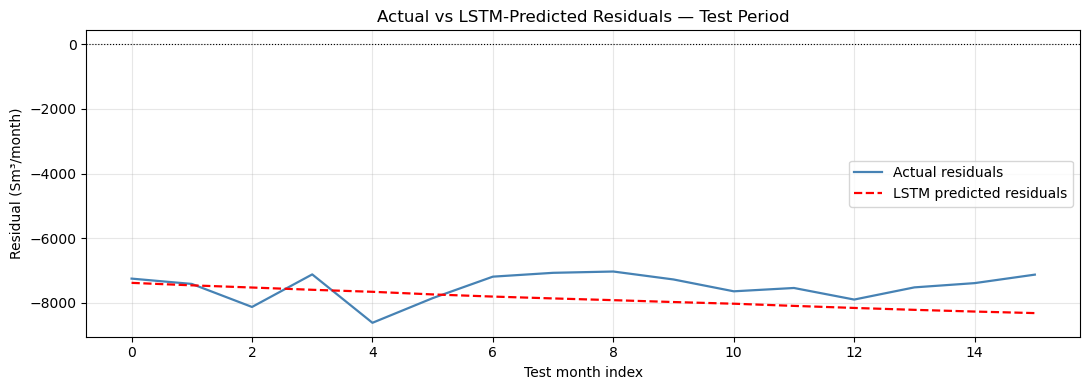

Saved: fig_09_residual_pred_vs_actual.png


In [12]:
# Predicted residuals vs actual residuals (quality check on LSTM residual learning)
actual_res_test = actual_test_aligned - trend_test_aligned

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(actual_res_test, color='steelblue', lw=1.6, label='Actual residuals')
ax.plot(res_pred_orig,   color='red',       lw=1.6, linestyle='--', label='LSTM predicted residuals')
ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.set_title('Actual vs LSTM-Predicted Residuals — Test Period', fontsize=12)
ax.set_xlabel('Test month index')
ax.set_ylabel('Residual (Sm³/month)')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_09_residual_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_09_residual_pred_vs_actual.png')

## Step 8 — Save Models & Predictions for Notebook 4

In [13]:
# Save Keras models in native format
model_hybrid.save(f'{OUTPUT_DIR}/model_hybrid_lstm.keras')
model_lstm_solo.save(f'{OUTPUT_DIR}/model_standalone_lstm.keras')

prediction_artefacts = {
    'n_pred'               : n_pred,
    'pred_indices'         : pred_indices[:n_pred],
    'actual_test_aligned'  : actual_test_aligned,
    'trend_test_aligned'   : trend_test_aligned,
    'hybrid_pred'          : hybrid_pred,
    'dca_pred'             : dca_pred,
    'solo_lstm_pred'       : solo_pred,
    'res_pred_orig'        : res_pred_orig,
    'actual_res_test'      : actual_test_aligned - trend_test_aligned,
    'res_abs_max'          : res_abs_max,
    'history_hybrid_loss'  : history_hybrid.history['loss'],
    'history_hybrid_val'   : history_hybrid.history['val_loss'],
    'history_solo_loss'    : history_solo.history['loss'],
    'history_solo_val'     : history_solo.history['val_loss'],
    'LOOKBACK'             : LOOKBACK,
    'HORIZON'              : HORIZON,
}

with open(f'{OUTPUT_DIR}/prediction_artefacts.pkl', 'wb') as f:
    pickle.dump(prediction_artefacts, f)

print('Artefacts saved successfully ✓')
print('Notebook 3 complete ✓  →  proceed to 04_Evaluation.ipynb')

Artefacts saved successfully ✓
Notebook 3 complete ✓  →  proceed to 04_Evaluation.ipynb


### Visualize pickle file

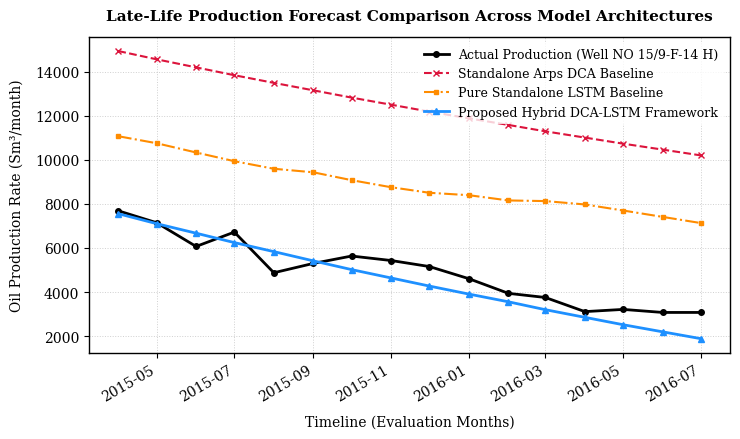

In [3]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt

# --- PEP 8 COMPLIANT PATH SPLITTING ---
OUTPUT_DIR = (
    r"C:\Users\StephenIheagwara\Documents\Mind\ICT_Literature\AFIT"
    r"\BSc_Project_Supervision_Computer_Science\2025_2026\Shade"
    r"\publish_shade\pipeline_outputs"
)

# 1. Verify and reload the saved pickle file
preds_file = f'{OUTPUT_DIR}/prediction_artefacts.pkl'
clean_file = f'{OUTPUT_DIR}/f14h_clean.csv'

if not os.path.exists(preds_file):
    raise FileNotFoundError(f"Could not find the pickle file at: {preds_file}")

with open(preds_file, 'rb') as f:
    preds_data = pickle.load(f)

# Reload the clean master dataframe to get the master dates timeline
df_clean_master = pd.read_csv(clean_file, parse_dates=['Date'])
master_dates = df_clean_master['Date'].values

# 2. Extract arrays from the loaded 'preds_data' dictionary
actual_vals = preds_data['actual_test_aligned']
hybrid_vals = preds_data['hybrid_pred']
dca_vals    = preds_data['dca_pred']
lstm_vals   = preds_data['solo_lstm_pred']
indices     = preds_data['pred_indices']

# Align indices with chronological datetime objects
timeline_dates = pd.to_datetime(master_dates[indices])

# 3. Configure elegant journal aesthetics (IEEE/Elsevier style)
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.linewidth"] = 1.0

fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=100)

# 4. Plot curves over your test timeline
ax.plot(timeline_dates, actual_vals, color="black", linestyle="-", linewidth=2.0, marker='o', markersize=4, label="Actual Production (Well NO 15/9-F-14 H)")
ax.plot(timeline_dates, dca_vals, color="crimson", linestyle="--", linewidth=1.5, marker='x', markersize=4, label="Standalone Arps DCA Baseline")
ax.plot(timeline_dates, lstm_vals, color="darkorange", linestyle="-.", linewidth=1.5, marker='s', markersize=3, label="Pure Standalone LSTM Baseline")
ax.plot(timeline_dates, hybrid_vals, color="dodgerblue", linestyle="-", linewidth=2.0, marker='^', markersize=4, label="Proposed Hybrid DCA-LSTM Framework")

# 5. Labeling, Grids, and Legend Formatting
ax.set_title("Late-Life Production Forecast Comparison Across Model Architectures", fontsize=11, fontweight="bold", pad=12)
ax.set_xlabel("Timeline (Evaluation Months)", fontsize=10, labelpad=8)
ax.set_ylabel("Oil Production Rate (Sm³/month)", fontsize=10, labelpad=8)

# Format and auto-rotate dates so they look professional on the x-axis
fig.autofmt_xdate()

ax.grid(True, linestyle=":", alpha=0.6, linewidth=0.7)
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", fontsize=9)

plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/figure5_forecast_comparison.png",
    format="png",
    dpi=300,
    bbox_inches="tight",
)
plt.show() # <-- This forces the visual figure window to render right inside your notebook!